# Case 2b control -- M06 (unshaded reference, day before Morning)

**Dissertation Chapter 6, Section 6.2.2, "Temporal Velocity Changes as a Reaction to Leaf Shading" (p. 117):**

> For context, additional tracer data from unshaded measurements on the same plant were
> analyzed. Three hours prior to the "Morning" measurement, velocity was 5.47 +/- 0.07 mm/min,
> and on the previous day at a similar time it was 3.51 +/- 0.06 mm/min. For the "Afternoon"
> case, velocities were 6.38 +/- 0.01 mm/min three hours earlier, and 4.12 +/- 0.04 mm/min the
> day before.

- Data: `Phas_6_M06_Internode_below_leaf.txt`.
- Model: single MCT (2-channel) unit, with a TubularReactor boundary segment ("stem"), constant flow rate, no time-varying velocity profile (unshaded, no shading
  perturbation applied) -- 6 parameters total.

## Imports

In [1]:
from CADETProcess.processModel import Inlet, MCT, Outlet, TubularReactor
from CADETProcess.processModel import ComponentSystem, MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet, Process
from CADETProcess.simulator import Cadet
from CADETProcess.optimization import OptimizationProblem, NelderMead, TrustConstr
from scipy.ndimage import gaussian_filter1d

from IPython import display

from utils import compute_jacobian, compute_parameter_uncertainties, interpolate_cb_from_simulation_results, plot_live_fit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.makedirs("output/figures", exist_ok=True)

## Load and preprocess experimental data

In [3]:
df = pd.read_csv("data/case2b_M06_internode.csv", index_col=0)
df.columns = df.columns.astype(float)  # CSV headers are strings; these are numeric distances (mm)

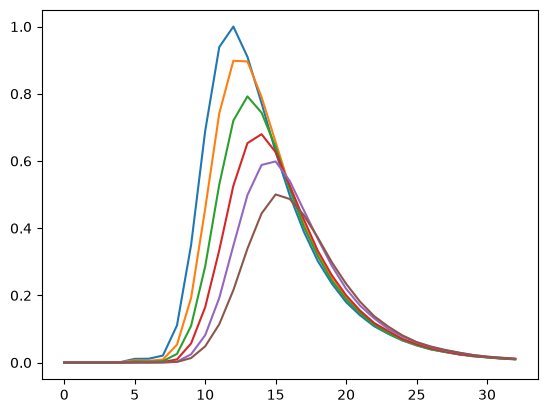

In [4]:
xi=list(df.columns)
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

xi=list(np.array(xi)[[6,7,8,9,10,11]])

exp_data = data_cor*np.exp(-0.000567*60*t.reshape(len(t),1))

normalized_data = (data_cor[:,[6,7,8,9,10,11]].T  - data_cor[:,[6,7,8,9,10,11]].T .min(axis=1, keepdims=True))

normalized_data[:, :2] = 0

normalized_data=normalized_data.T

# Transpose and smooth
monotonic_data = normalized_data.copy().T

for i in range(monotonic_data.shape[0]):
    # Smooth first 4 values only
    monotonic_data[i, :3] = gaussian_filter1d(monotonic_data[i, :3], sigma=0.5)
    
# Transpose back
smooth_exp_data = monotonic_data.T / np.exp(0.000567*60*t.reshape(len(t), 1))

exp_data = smooth_exp_data / np.max(smooth_exp_data)

num_new_rows = 3
num_columns = exp_data.shape[1]

new_rows = np.zeros((num_new_rows, num_columns))

exp_data = np.vstack((new_rows, exp_data))
t = np.hstack((t,[150.,155.,160.]))

plt.plot(exp_data)

## Process model and parameter normalization

In [12]:
def setup_process(x):
    
    p_volumetric_flow_rate_const_t0 = x[0]
    p_mct1_e12 = x[1]
    p_total_porosity = x[2]
    p_col_dispersion = x[3]
    p_x0 = x[4]
    p_mct_disp = x[5]

        
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    tube = TubularReactor(component_system, name='stem')
    mct1 = MCT(component_system, nchannel=2, name='mct1')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 30

    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system

    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(tube)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(outlet)
    
    inlet.flow_rate = p_volumetric_flow_rate_const_t0
    
    tube.length = p_x0
    tube.axial_dispersion = 0
    tube.diameter = np.sqrt(1/np.pi)

    leaf.total_porosity = p_total_porosity
    leaf.length = 0.01
    leaf.diameter = np.sqrt(1/np.pi)*17
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, tube)
    mct_flow_sheet.add_connection(tube, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, outlet, origin_port = 'channel_0')
 
    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[-1]/1000
    
    mct1.channel_cross_section_areas = [1,1] 
    
    mct1.axial_dispersion = p_mct_disp
    
    mct1.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix = np.array([
                                    [[0.0], [p_mct1_e12]],
                                    [[0.0], [0.0]],
                                    ])
                                

    process.cycle_time = 60*t[-1]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [1],0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [1],0.1)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0],6*60)
        

        
    return process

In [13]:
param_bounds = {
    'volumetric_flow_rate_const': (1e-05, 0.0002),
    'mct1_e12': (1.53039589e-05, 0.612158354),
    'total_porosity': (0.1, 0.99),
    'col_dispersion': (2.83319089e-12, 0.000113327635),
    'x0': (0.0001, 0.01),
    'mct_disp': (2.83319089e-10, 0.000113327635),
}

problem = OptimizationProblem("case2b_control_M10_day_before")
for pname, (lb, ub) in param_bounds.items():
    problem.add_variable(pname, evaluation_objects=None, lb=lb, ub=ub, normalization="auto")


## Objective function

`_forward_model` runs the simulation once; `objective` (scalar SSQ, for the optimizer) and `residuals` (weighted residual vector, for the Jacobian/uncertainty estimate below) both build on it instead of duplicating the simulation call.

In [14]:
def _forward_model(x):
    """Simulate the process; return (calc_data, time_new)."""
    process = setup_process(x)

    simulation_results = simulator.simulate(process)
    time_new = np.arange(t[0] * 60, t[-1] * 60 + 5 * 60, 5 * 60)

    mct1 = process.flow_sheet.units[3]

    lenghts = [v / 1000 for v in xi]
    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new=eval_location1)
    calc_data = np.sum(cb_mct1, axis=2).squeeze()
    calc_data = calc_data / np.max(calc_data)

    return calc_data, time_new

def objective(x):
    """NMSRE = mean((calc - exp)^2) / mean(exp^2); used as the optimizer's objective."""
    calc_data, time_new = _forward_model(x)
    residuals = calc_data - exp_data
    nmsre = np.mean(residuals ** 2) / np.mean(exp_data ** 2)
    _obj_history.append(nmsre)
    if _live_plot_active:
        plot_live_fit(time_new, calc_data, exp_data, _obj_history)
    return nmsre

def residuals(x):
    """Weighted residual vector; used for the numerical Jacobian / uncertainty estimate."""
    calc_data, time_new = _forward_model(x)
    residuals = calc_data - exp_data
    return residuals.ravel() / np.sqrt(np.mean(exp_data ** 2))

problem.add_objective(objective, n_objectives=1)

## Plotting helper

In [15]:
_obj_history = []
_live_plot_active = False

In [16]:
simulator = Cadet()    
simulator.time_resolution = 60
simulator.use_dll = True

## Optimization

Local refinement (Nelder-Mead, then L-BFGS-B) from a fixed starting point.

In [19]:
x_best_fit_published = np.array([5.85548021e-05, 1.32093117e-04, 2.12562439e-01, 2.46891222e-09,
       3.34077450e-03, 5.79689583e-08])

def run_optimization(optimize=False, live_plot=False, method="nm+tc", x0=None):
    """
    optimize  : False  return x_best_fit_published without running the optimizer
                True   run the optimizer and return the converged x
    method    : "nm"     NelderMead only
                "tc"     TrustConstr only
                "nm+tc"  NelderMead then TrustConstr
                "tc+nm"  TrustConstr then NelderMead
    x0        : starting point in real units; defaults to x_best_fit_published
    live_plot : show live fit and objective progress during optimization
    """
    global _live_plot_active, _obj_history
    if not optimize:
        return x_best_fit_published

    if x0 is None:
        x0 = x_best_fit_published

    _live_plot_active = live_plot
    _obj_history = []

    if method in ("nm", "nm+tc"):
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    if method in ("tc", "nm+tc", "tc+nm"):
        tc = TrustConstr()
        tc.gtol = 1e-5
        tc.xtol = 1e-5
        tc.barrier_tol = 1e-5
        result_tc = tc.optimize(problem, x0=x0, save_results=False)
        x0 = result_tc.x[0]

    if method == "tc+nm":
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    x_best_fit = x0
    for pname, value in zip(param_bounds.keys(), x_best_fit):
        print(f"{pname:<35}{value:<20.8e}")
    _live_plot_active = False
    return x_best_fit

x_best_fit = run_optimization()

## Final fit figure (`Figures/M06_control.pdf`)

In [ ]:
def plot_for_publication(x):
    process = setup_process(x)
    plt.style.use("default")

    simulation_results = simulator.simulate(process)
    time_new = np.arange(t[0] * 60, t[-1] * 60 + 60, 60)

    mct1 = process.flow_sheet.units[3]
    eval_locations = [v / 1000 for v in xi]

    cb_mct1 = interpolate_cb_from_simulation_results(
        simulation_results, mct1, time_new, axial_positions_new=eval_locations
    )
    calc_data = np.sum(cb_mct1, axis=2).squeeze()
    calc_data = calc_data / np.max(calc_data)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.plot(time_new / 60, calc_data, label="Simulated Data", linewidth=1.5)
    plt.gca().set_prop_cycle(None)
    plt.plot(t, exp_data, ".", markersize=8, label="Experimental Data")

    handles, labels = plt.gca().get_legend_handles_labels()
    seen = {}
    unique_h, unique_l = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen[l] = True; unique_h.append(h); unique_l.append(l)
    plt.legend(unique_h, unique_l, fontsize=12)
    plt.xlabel("Time [min]", fontsize=15)
    plt.ylabel("Activity [a.u.]", fontsize=15)
    plt.savefig("output/figures/M06_control.pdf", format="pdf")

In [ ]:
plt.close("all")
plot_for_publication(x_best_fit)

## Parameter uncertainties and final velocity

In [20]:
param_uncertainties = compute_parameter_uncertainties(residuals, x_best_fit, use_pinv=False)
rel_param_uncertainties = param_uncertainties / np.abs(x_best_fit)

for i, uncertainty in enumerate(rel_param_uncertainties):
    print(f"Parameter {i}: \u00b1{uncertainty * 100:.2f}%")

q_const = x_best_fit[0]
velocity_mm_per_min = q_const * (1 / 1.66667e-5)
velocity_uncertainty_pct = rel_param_uncertainties[0] * 100
print(f"\nVelocity: {velocity_mm_per_min:.2f} \u00b1 {velocity_uncertainty_pct:.2f}% mm/min")

Parameter 0: ±1.65%
Parameter 1: ±10.01%
Parameter 2: ±6.26%
Parameter 3: ±18.14%
Parameter 4: ±946.56%
Parameter 5: ±35.62%

Velocity: 3.51 ± 1.65% mm/min
